# 🔍 Analyse post-entraînement du modèle DistilBERT

Ce notebook vise à :
1. **Analyser les erreurs** du modèle sur le jeu de test.
2. **Explorer la calibration** des prédictions.
3. **Étudier l'effet du seuil de décision** (au lieu de 0.5) pour améliorer les performances selon le contexte d'usage.

Les données de test sont disponibles dans `notebooks/data/test.csv`.


In [1]:
import sys
import os
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    f1_score,
    accuracy_score, 
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.calibration import calibration_curve

# Reduce TensorFlow log level to warn
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import tensorflow as tf
from transformers import DistilBertTokenizerFast, TFAutoModel
from tensorflow_addons.metrics import F1Score
from IPython.display import display

# Ajout du chemin racine du projet pour permettre les imports de modules locaux
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from lucenai.training.model import load_best_model_and_tokenizer
from lucenai.config.settings import TRAINING_PARAMS, MODEL_PATHS, LOGGING_PATHS


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


## 📦 Chargement du modèle et du tokenizer

In [2]:
model_path = MODEL_PATHS.best_weights
tokenizer_path = MODEL_PATHS.best_tokenizer

model, tokenizer = load_best_model_and_tokenizer(model_path, tokenizer_path)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding model architecture...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


🏗️ Building deep architecture...
   ✅ Input layers created
   ✅ DistilBERT integrated
   ✅ [CLS] token extracted
   ✅ Deep classification head added

✅ Model successfully built!
📦 Loading model weights from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model
✅ Weights loaded successfully.


## 📄 Chargement des données de test

In [3]:
try:
    df_test = pd.read_csv("./data/test.csv")
    print(f"✅ Fichier chargé avec succès, Nombre d'échantillons : {len(df_test)}")
    display(df_test.head(10))
except FileNotFoundError:
    print("❌ Erreur : le fichier spécifié est introuvable.")
except pd.errors.EmptyDataError:
    print("❌ Erreur : le fichier est vide.")
except pd.errors.ParserError:
    print("❌ Erreur : échec de l'analyse du fichier.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

✅ Fichier chargé avec succès, Nombre d'échantillons : 880


,id,full_text,clean_text,label
0,5856,Ok fine https://t.co/sG6IbiNBSA,ok fine,1
1,2165,Name: Bodhi\nSymbol: BOT\n24 hour change: -10....,name bodhi symbol bot 24 hour change -10.2 per...,0
2,3347,RT @tokentalkco: Soon There Will Be More Bitco...,soon there will be more bitcoin investors than...,1
3,4568,British Charity Aims to Improve Maritime Safet...,british charity aims to improve maritime safet...,1
4,3986,NEW Traffic Method &amp; Free Thousands Of $$ ...,new traffic method free thousands of in online...,1
5,5704,#Coinbase Is In Talks to Buy One of #Bitcoin's...,is in talks to buy one of s best funded startups,1
6,1450,RT @BrowsersLab: Our pre-sale is now live! \n\...,our presale is now live head over the and see ...,1
7,3770,$TOPS 👈👀🚀 ended dilution going to see a seriou...,tops 👈👀🚀 ended dilution going to see a serious...,0
8,5636,Bitcoin Hits New All-Time High https://t.co/RG...,bitcoin hits new alltime high,1
9,5193,Name: Matchpool\nSymbol: GUP\n24 hour change: ...,name matchpool symbol gup 24 hour change -15.5...,0


## ✏️ Préparation des données pour le modèle

In [4]:
X_test = tokenizer(
    df_test["clean_text"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=TRAINING_PARAMS.max_len,
    return_tensors="tf"
)

# Cibles réelles
y_true = df_test["label"].values
# Prédictions de probabilité du modèle
y_pred_proba = model.predict(dict(X_test)).squeeze()


28/28 [==============================] - 36s 1s/step


## 📈 Performance du modèle (entraînement)

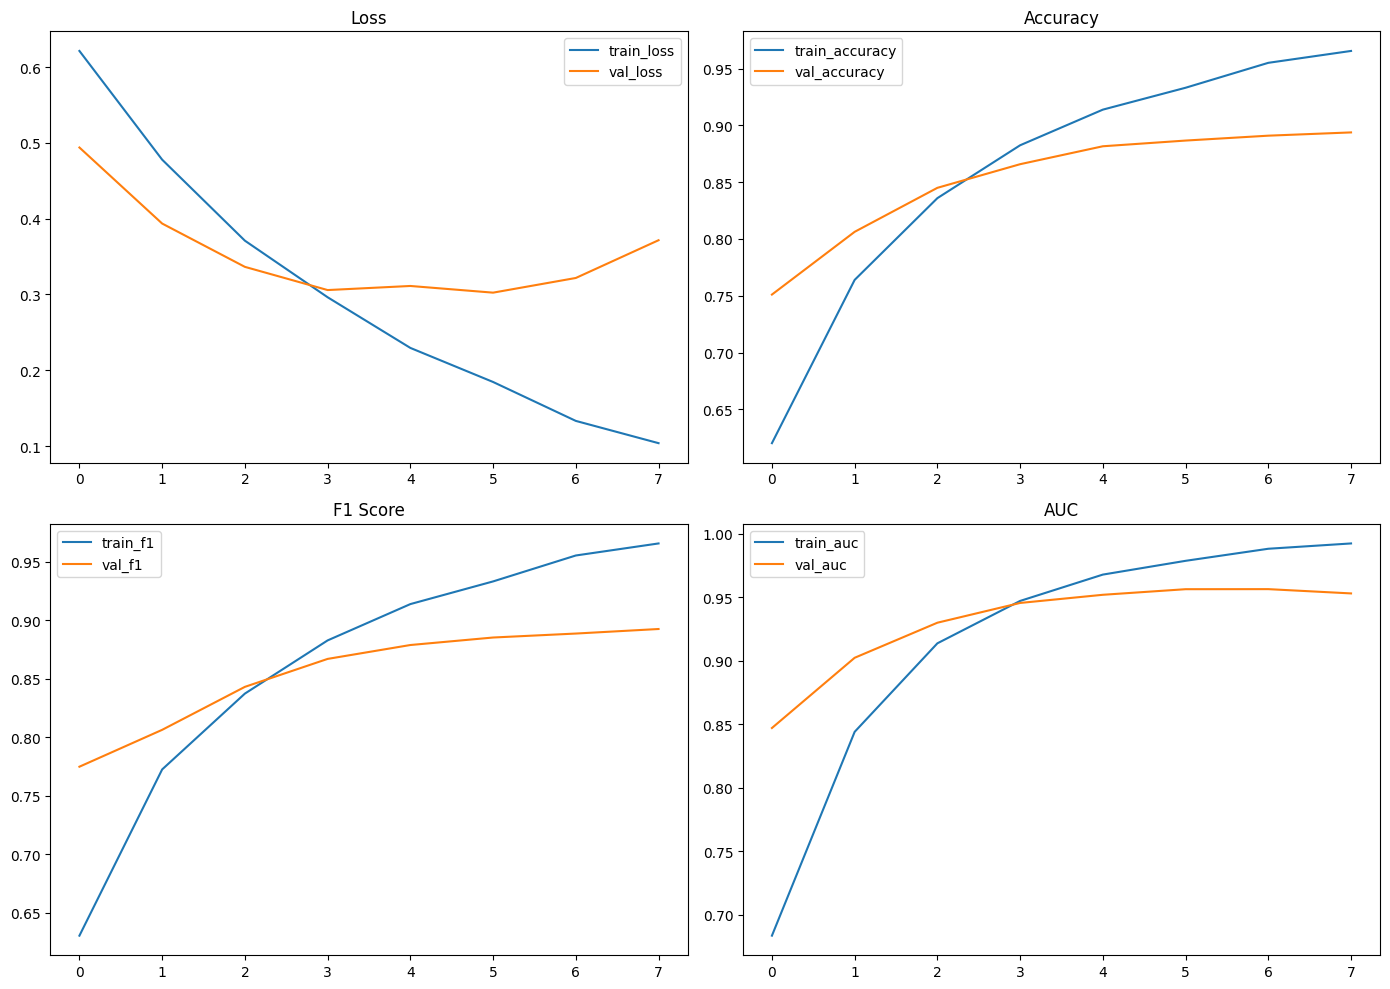

In [5]:
log_df = pd.read_csv(LOGGING_PATHS.csv_log_file)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axs[0, 0].plot(log_df["epoch"], log_df["loss"], label="train_loss")
axs[0, 0].plot(log_df["epoch"], log_df["val_loss"], label="val_loss")
axs[0, 0].set_title("Loss")
axs[0, 0].legend()

# Accuracy
axs[0, 1].plot(log_df["epoch"], log_df["accuracy"], label="train_accuracy")
axs[0, 1].plot(log_df["epoch"], log_df["val_accuracy"], label="val_accuracy")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# F1
axs[1, 0].plot(log_df["epoch"], log_df["f1_score"], label="train_f1")
axs[1, 0].plot(log_df["epoch"], log_df["val_f1_score"], label="val_f1")
axs[1, 0].set_title("F1 Score")
axs[1, 0].legend()

# AUC
axs[1, 1].plot(log_df["epoch"], log_df["auc"], label="train_auc")
axs[1, 1].plot(log_df["epoch"], log_df["val_auc"], label="val_auc")
axs[1, 1].set_title("AUC")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

## ❌ Analyse des erreurs de prédiction

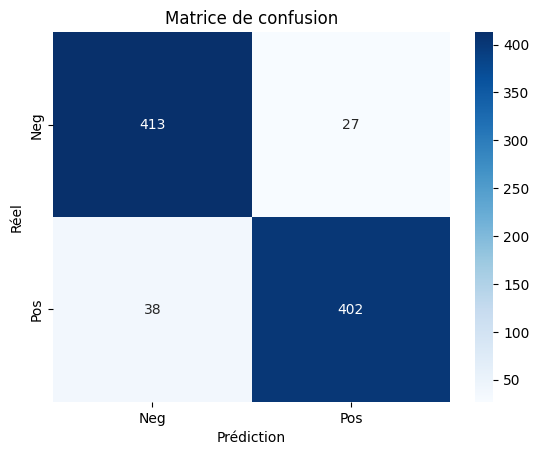

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       440
           1       0.94      0.91      0.93       440

    accuracy                           0.93       880
   macro avg       0.93      0.93      0.93       880
weighted avg       0.93      0.93      0.93       880



In [6]:
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_true, y_pred))

## 🔍 Analyse des erreurs : Faux positifs et faux négatifs

In [7]:
from IPython.display import display, HTML

def display_errors_with_full_text(df: pd.DataFrame, title: str, n: int = 5):
    """Affiche une vue enrichie des erreurs avec clean_text, full_text et probabilité."""
    rows = []
    for _, row in df.head(n).iterrows():
        html_row = f"""
        <div style="margin-bottom: 1.5em; padding: 0.5em; border-bottom: 1px solid #ddd;">
            <div><strong>🧹 Clean:</strong> {row['clean_text']}</div>
            <div style="color: #555;"><strong>🗒️ Original:</strong> {row['full_text']}</div>
            <div style="text-align: right;"><strong>🔢 Proba:</strong> {row['prob']:.4f}</div>
        </div>
        """
        rows.append(html_row)

    display(HTML(f"<h4>{title}</h4>" + "".join(rows)))

# Calcul des prédictions binaires
y_pred = (y_pred_proba > 0.5).astype(int)

# Création d’un DataFrame pour visualiser les erreurs
df_errors = df_test.copy()
df_errors["y_true"] = y_true
df_errors["y_pred"] = y_pred
df_errors["prob"] = y_pred_proba

# Afficher les faux positifs
false_positives = df_errors[(df_errors["y_true"] == 0) & (df_errors["y_pred"] == 1)]
display_errors_with_full_text(false_positives, "🔴 Faux positifs", n=5)

# Afficher les faux négatifs
false_negatives = df_errors[(df_errors["y_true"] == 1) & (df_errors["y_pred"] == 0)]
display_errors_with_full_text(false_negatives, "🔵 Faux négatifs", n=5)

## 📉 Courbe ROC & Précision-Rappel

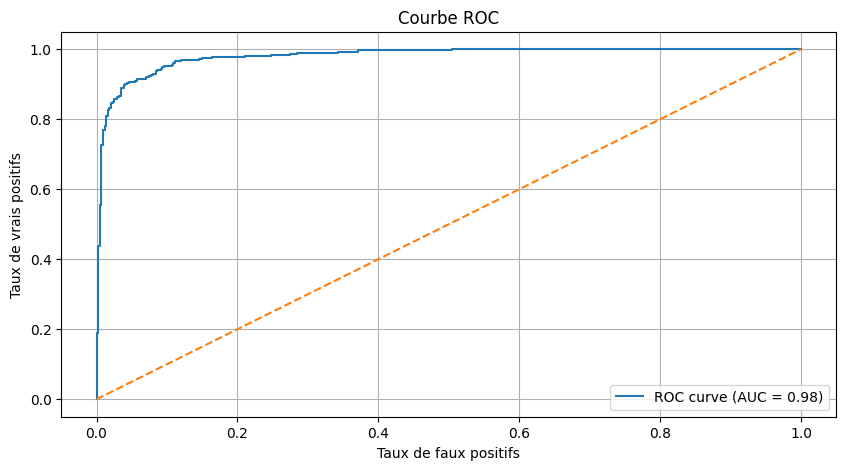

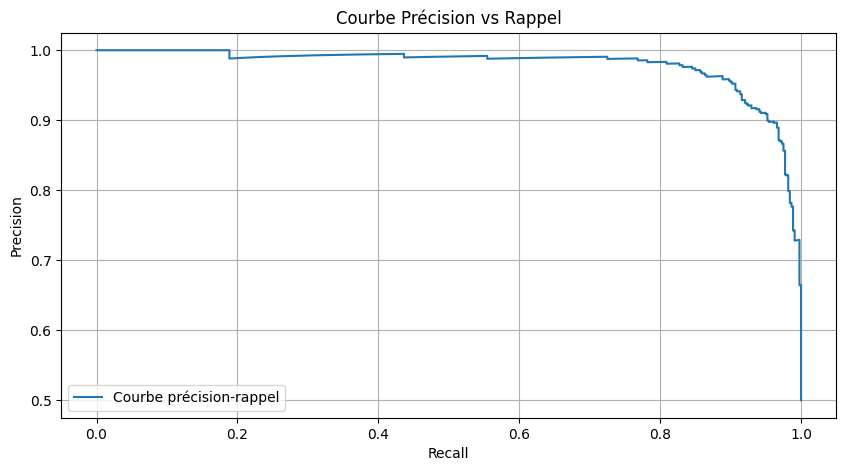

In [8]:
# ROC
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Courbe ROC")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend()
plt.grid()
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)

plt.figure(figsize=(10, 5))
plt.plot(recall, precision, label="Courbe précision-rappel")
plt.title("Courbe Précision vs Rappel")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend()
plt.show()

## 🎛️ Calibration des probabilités
La calibration permet de vérifier si les probabilités prédites par le modèle correspondent bien à la réalité observée.
Dans le graphique ci-dessous :
- La courbe en pointillés représente une calibration parfaite : les probabilités prédites sont parfaitement alignées avec la réalité.
- La courbe bleue montre la calibration réelle du modèle.
    - Si elle est au-dessus de la diagonale, le modèle est sous-confiant (il prédit trop bas).
    - Si elle est en dessous, il est trop confiant (il surestime les prédictions).

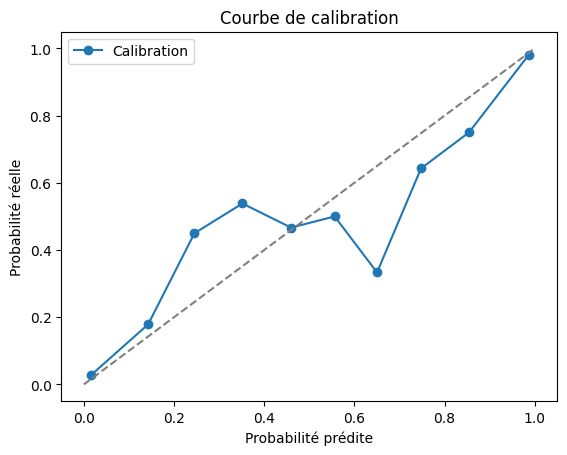

In [9]:
prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Courbe de calibration")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité réelle")
plt.legend()
plt.show()

## 🧮 Étude du seuil de décision optimal
Dans cette section, nous explorons l’impact du seuil de décision sur la performance du modèle, en traçant l’évolution du F1-score pour différents seuils compris entre 0 et 1.
Le seuil optimal correspond à celui qui maximise le F1-score.

🎯 Seuil optimal F1: 0.27 (F1 = 0.9301)


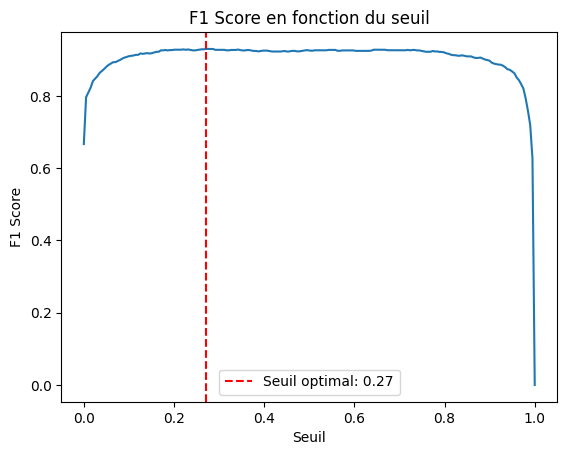

In [10]:
thresholds = np.linspace(0, 1, 200)
f1s = [f1_score(y_true, y_pred_proba >= t) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f"🎯 Seuil optimal F1: {best_t:.2f} (F1 = {max(f1s):.4f})")

plt.plot(thresholds, f1s)
plt.axvline(best_t, color='r', linestyle='--', label=f'Seuil optimal: {best_t:.2f}')
plt.title("F1 Score en fonction du seuil")
plt.xlabel("Seuil")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


## 📊 Comparaison des matrices de confusion (0.5 vs seuil optimal)

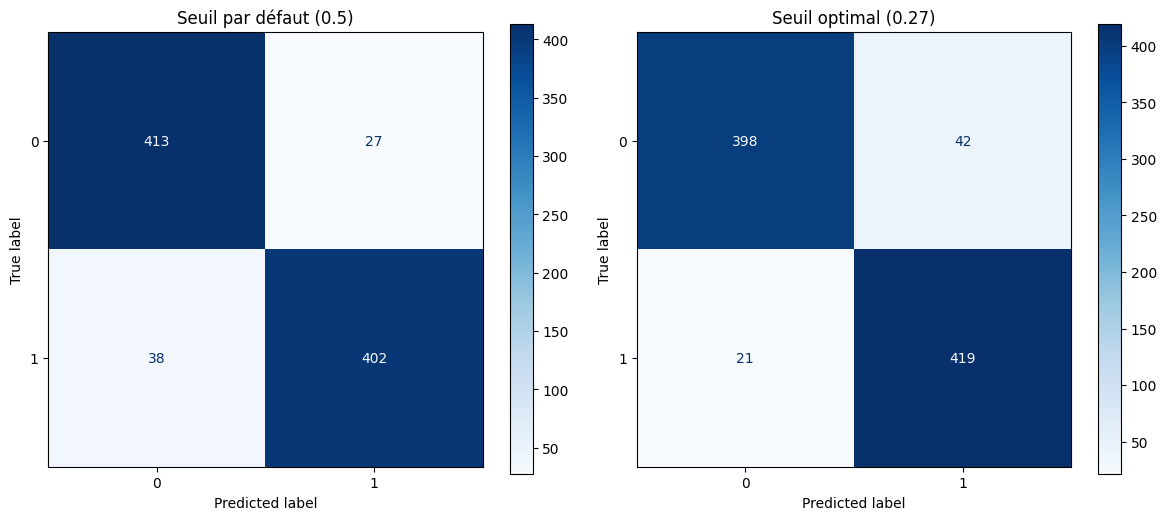

In [11]:
# Prédictions au seuil par défaut
y_pred_default = (y_pred_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_true, y_pred_default)

# Prédictions au seuil optimal
y_pred_opt = (y_pred_proba >= best_t).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice par défaut
ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], cmap="Blues", values_format='d')
axes[0].set_title("Seuil par défaut (0.5)")

# Matrice seuil optimal
ConfusionMatrixDisplay(cm_opt).plot(ax=axes[1], cmap="Blues", values_format='d')
axes[1].set_title(f"Seuil optimal ({best_t:.2f})")

plt.tight_layout()
plt.show()

## ✅ Evaluation finale du modèle

In [13]:
print("📊 Évaluation finale du modèle :")
print(f"✅ Accuracy       : {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Precision      : {precision_score(y_true, y_pred):.4f}")
print(f"✅ Recall         : {recall_score(y_true, y_pred):.4f}")
print(f"✅ F1 Score       : {f1_score(y_true, y_pred):.4f}")
print(f"✅ ROC AUC        : {roc_auc_score(y_true, y_pred_proba):.4f}")


# Définition du seuil optimal (issu de l'analyse ROC/Precision-Recall)
threshold = 0.27

# Convertir les probabilités en prédictions binaires
y_pred_optimal = (y_pred_proba >= threshold).astype(int)
report = classification_report(y_true, y_pred_optimal, output_dict=True)

# Conversion en DataFrame pour affichage propre
report_df = pd.DataFrame(report).transpose()

# Arrondi des valeurs
report_df = report_df.round(2)

# Optionnel : renommer les index pour les rendre plus lisibles
report_df.rename(index={
    "0": "0 (négatif)",
    "1": "1 (positif)",
    "accuracy": "Accuracy",
    "macro avg": "Macro avg",
    "weighted avg": "Weighted avg"
}, inplace=True)

# Réorganiser les colonnes
report_df = report_df[["precision", "recall", "f1-score", "support"]]

# Affichage
import IPython
IPython.display.display(report_df)

📊 Évaluation finale du modèle :
✅ Accuracy       : 0.9261
✅ Precision      : 0.9371
✅ Recall         : 0.9136
✅ F1 Score       : 0.9252
✅ ROC AUC        : 0.9801


,precision,recall,f1-score,support
0 (négatif),0.95,0.90,0.93,440.00
1 (positif),0.91,0.95,0.93,440.00
Accuracy,0.93,0.93,0.93,0.93
Macro avg,0.93,0.93,0.93,880.00
Weighted avg,0.93,0.93,0.93,880.00


## ✅ Conclusion
Le modèle fine-tuné à partir de DistilBERT s’avère bien adapté à la classification de sentiments dans des tweets liés aux crypto-monnaies.<br>Il offre de bonnes performances générales, aussi bien en précision qu’en rappel, sur les deux classes.

Une analyse fine du seuil de décision a permis d’identifier une valeur optimale à 0.27 (au lieu du seuil standard de 0.5), qui maximise le F1-score à 0.93.<br>Ce choix est validé par les matrices de confusion comparatives, qui montrent un meilleur équilibre entre faux positifs et faux négatifs.<br>Ce comportement s’explique par des prédictions souvent moins tranchées du modèle, typiques des textes courts et ambigus.

👉 Le modèle est fiable, bien calibré, et suffisamment performant pour être intégré dans une API ou déployé en environnement de production.